# **1. Title**

**Model-Based Reflex Agent for Battery-Aware Multi-Floor Mall Cleaning**

# **2. Aim**
**To design and implement a vacuum cleaning agent that autonomously cleans multiple sections of a multi-floor shopping mall, while managing two finite resources i.e, battery charge and dust container capacity, without any manually scripted sequence of actions.**

# **3. Objectives**



The main objectives of this experiment are:
1. To represent a **multi-floor mall** as an environment, where each section has its own dirty/clean status and a floor assignment.

2. To make the agent **decide its own next action** from its current state, instead of following a fixed, hardcoded order.
3. To make **floor changes cost more** than same-floor movement, so the agent's battery use reflects real movement effort.
4. To deduct battery for **every action** like, cleaning as well as movement and no matter what's the purpose (cleaning route, charging trip, or emptying trip).
5. To calculate the **battery required to reach the charging point dynamically**, based on the agent's current location, instead of a fixed percentage.
6. To always keep a **minimum battery reserve** on arrival at the charging point.
7. To detect a **full dust container immediately after cleaning** and divert to the Basement before visiting any further section.
8. To make the agent **return to a home position** (Maintenance Room) once all cleaning is done, emptying leftover dust on the way.
9. To display the agent's **Score, Battery, and Dust Container level** after every action for step-by-step observability.

# **4. Experiment Outcome**



*  The agent starts at the **Maintenance Room** and enters its decision loop.

*  It visits sections **one at a time**, cleaning dirty ones and updating Battery, Dust Container, and Score after each action.

* When battery drops to the level **needed to just reach the Maintenance Room** (plus a safety margin), it interrupts cleaning, charges, and **resumes from the same spot.**
*  When the dust container becomes full, it **immediately detours** to the Basement. Therefore, no extra section is visited first.
* Once every section is clean, it does **not wander back** to its starting section instead it **goes straight from the last cleaned section** to empty dust (if needed) and park at the Maintenance Room.
* The run ends with a **Final Score**, reflecting net cleaning benefit minus movement/floor-change cost.

# **5. Conceptual Details**


**5.1 Classification of the Agent**

This is a Model-Based Reflex Agent - not a simple reflex agent.

* It carries **internal state** across cycles: *battery, dustbin, score, position* . None of which is directly visible from the current percept alone.
* It holds an internal **model of the environment's structure** i.e, the *floors* dictionary  and uses it to **predict outcomes before acting.**
* Example: *battery_needed()* calculates the cost of a hypothetical trip to the Maintenance Room **before committing** to it and this predictive reasoning is what makes it model-based rather than purely reactive.

**5.2 Environment Representation**

* The mall is modeled as named **sections**, each holding a **dirty/clean value**(Randomly).
* A parallel **floors mapping** assigns every section (plus Maintenance Room and Basement) to a floor number.
* Separating "what needs cleaning" from "where it is" lets movement cost depend on **actual mall layout**, not an arbitrary order.

**5.3 Movement and Floor-Change Cost Model**

* All movement - routine steps, charging trips, dust-emptying trips will passes through **one shared method**: move_to().
* **Same floor** --> 5% battery, −1 score.
* **Floor change** --> 10% battery, −3 score. *(For both, One at a time or Two at a time)*
* Because every movement type reuses this one method, the cost logic **cannot drift** between different parts of the agent's behavior.

**5.4 Cleaning and Dust Container Management**

* Cleaning a dirty section: **+5 score, +25% dust, −5% battery.**
* The dust container is checked **immediately after cleaning finishes** , not at the start of the next cycle.
* If full, the agent **interrupts its route instantly** and heads to the Basement, so it never carries a full container into another section.

**5.5 Dynamic Battery Threshold**

* Instead of a fixed number, *battery_needed()* computes the **actual cost to reach the Maintenance Room** from the agent's current position.
* Adds a **fixed 5% safety reserve** on top.
* Agent recharges only when current battery **falls to or below** this computed requirement, thats why guaranteeing it never arrives with negative charge.

**5.6 Decision Cycle**

* **All clean?** --> finish run.
* **Battery critical?** --> go charge.
* **Dirty section?** --> clean it, then immediately re-check all-clean and dust-full conditions.
* **Otherwise** --> move to the next section.

This fixed priority ensures **resource management always outranks** continuing the cleaning route.

**5.7 Termination Behavior**

* The finishing routine triggers the **moment the last dirty section is cleaned** and not after one more unnecessary move.
* From that exact position, it empties dust (if needed) and returns to the Maintenance Room from **a genuine completion point**, not an arbitrary stop.

# **6. Algorithm / Flowchart Details**


**6.1 Algorithm**

**Step 1**: Initialize the mall environment - assign dirty/clean status and floor number to each section.

**Step 2**: Initialize the agent at the Maintenance Room with full battery and empty dust container.

**Step 3**: Check if all sections are clean --> if yes, empty dust (if needed), return to Maintenance Room, terminate with final score.

**Step 4**: If agent is at Maintenance Room/Basement (start of run only) --> move to first section, repeat Step 3.

**Step 5**: Compute battery required to reach Maintenance Room (with reserve) from current position.

**Step 6**: If battery ≤ that requirement --> travel to Maintenance Room, recharge fully, return to the same section, repeat Step 3.

**Step 7**: If current section is dirty --> clean it (update score, dust, battery).

**Step 8**: Re-check all-clean condition --> if true, go to finishing routine from current position (Step 3 logic).

**Step 9**: If dust container full --> travel to Basement, empty it, return to current section, repeat Step 3.

**Step 10**: Move to next section in round, applying same-floor/floor-change cost.

**Step 11**: Repeat from Step 3 until termination.

**6.2 Environment Layout Diagram**




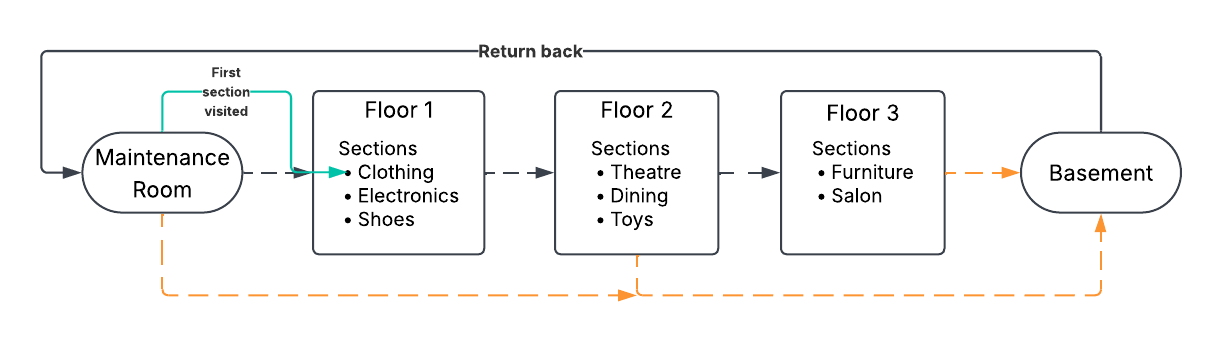



**6.3 Agent Decision Flowchart**



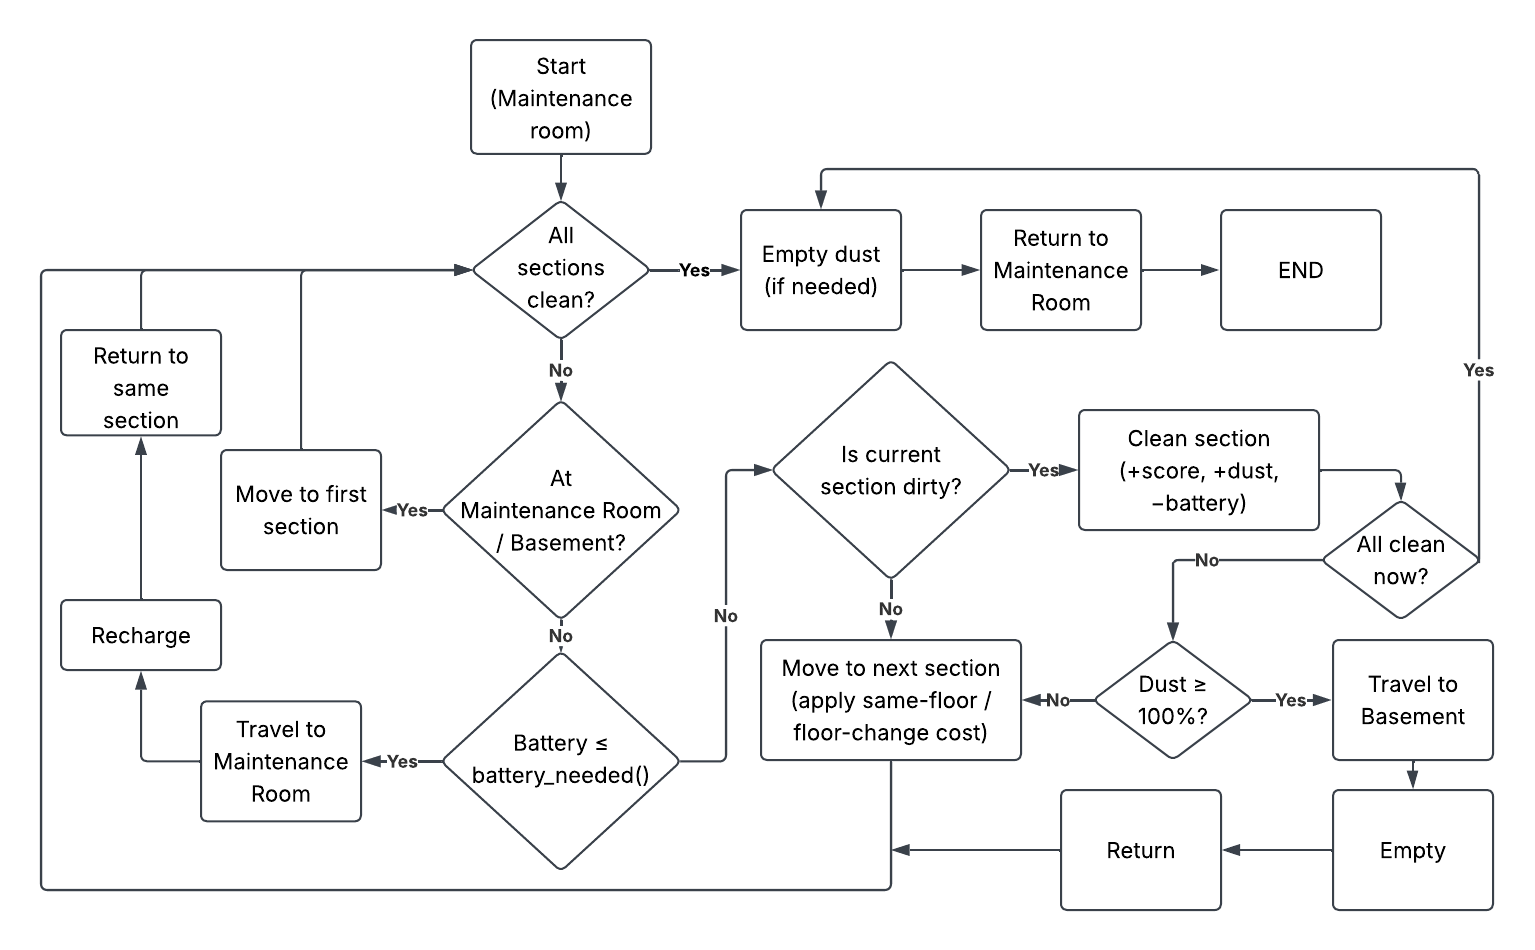



# **7. Code (Implementation)**

**Implementation follows this same structure**: Mall initialization (sections + floor mapping), floor-aware movement costing, priority-ordered decision cycle (all-clean check --> battery check --> clean --> dust check --> move), cleaning with dust/battery updates, and dynamic battery-threshold-based charging/emptying management.

In [ ]:
import random
import time

class Environment:
    def __init__(self):
        self.sections = {
            "Clothing section": random.randint(0, 1),
            "Electronics section": random.randint(0, 1),
            "Shoes section": random.randint(0, 1),
            "Theatre section": random.randint(0, 1),
            "Dining section": random.randint(0, 1),
            "Toys section": random.randint(0, 1),
            "Furniture section": random.randint(0, 1),
            "Salon section": random.randint(0, 1)
        }

        self.floors = {
            "Maintenance Room": 1,
            "Basement": 1,
            "Clothing section": 1,
            "Electronics section": 1,
            "Shoes section": 1,
            "Theatre section": 2,
            "Dining section": 2,
            "Toys section": 2,
            "Furniture section": 3,
            "Salon section": 3
        }

    def display(self):
        print("\nMall Section Status")
        for section in self.sections:
            print(section, "(Floor", self.floors[section], ") :", self.sections[section])


class Agent:
    def __init__(self, env):
        self.env = env
        self.charging_point = "Maintenance Room"
        self.basement = "Basement"
        self.position = self.charging_point
        self.score = 0
        self.battery = 100
        self.dustbin = 0

    def print_status(self):
        print("Score =", self.score, "| Battery =", self.battery, "% | Dust Container =", self.dustbin, "%")

    def is_all_clean(self):
        for section in self.env.sections:
            if self.env.sections[section] == 1:
                return False
        return True

    def finish(self):
        print("All Sections are Clean.")

        if self.dustbin > 0:
            print("Dust Container is not Empty. Going to Basement to Empty it.")
            self.move_to(self.basement)

            time.sleep(1)
            self.dustbin = 0
            print("Dust Container Emptied")

            self.move_to(self.charging_point)
            print("Robot Parked at", self.charging_point)

        print("Final Score =", self.score)

    def battery_needed(self, destination):
        reserve = 5

        if self.env.floors[self.position] != self.env.floors[destination]:
            cost = 10
        else:
            cost = 5

        return cost + reserve

    def move_to(self, new_position):
        old_position = self.position
        self.position = new_position

        if self.env.floors[old_position] != self.env.floors[new_position]:
            print("Changing Floor from", self.env.floors[old_position], "to", self.env.floors[new_position])
            self.score -= 3
            self.battery -= 10
        else:
            self.score -= 1
            self.battery -= 5

        print("Moving from", old_position, "to", new_position)
        self.print_status()

    def run(self):

        while True:

            print("\n----------------------------------------")

            if self.is_all_clean():
                self.finish()
                break

            if self.position == self.charging_point or self.position == self.basement:
                print("Robot is at", self.position)
                self.print_status()

                first_section = list(self.env.sections.keys())[0]
                self.move_to(first_section)

                self.env.display()
                continue

            required_battery = self.battery_needed(self.charging_point)

            if self.battery <= required_battery:
                print("Battery =", self.battery, "% | Need", required_battery, "% to reach Maintenance Room. Therefore, Going to Charge.")
                return_position = self.position
                self.move_to(self.charging_point)

                time.sleep(1)
                self.battery = 100
                print("Battery Charged to 100%")

                self.move_to(return_position)
                continue

            print("Robot is in", self.position, "(Floor", self.env.floors[self.position], ")")

            if self.env.sections[self.position] == 1:
                print(self.position, "is Dirty. Cleaning...")
                time.sleep(1)

                self.env.sections[self.position] = 0
                self.score += 5
                self.dustbin += 25
                self.battery -= 5

                print("Section Cleaned")
                self.print_status()

                if self.is_all_clean():
                    self.finish()
                    break

                if self.dustbin >= 100:
                    print("Dust Container is Full. Going to Basement to Empty it.")
                    return_position = self.position
                    self.move_to(self.basement)

                    time.sleep(1)
                    self.dustbin = 0
                    print("Dust Container Emptied")

                    self.move_to(return_position)
                    continue

            else:
                print(self.position, "is Already Clean")

            sections = list(self.env.sections.keys())
            index = sections.index(self.position)

            if index == len(sections) - 1:
                next_section = sections[0]
            else:
                next_section = sections[index + 1]

            self.move_to(next_section)

            self.env.display()


env = Environment()
env.display()

agent = Agent(env)

print("\nStarting Position:", agent.position)

agent.run()


Mall Section Status
Clothing section (Floor 1 ) : 1
Electronics section (Floor 1 ) : 1
Shoes section (Floor 1 ) : 0
Theatre section (Floor 2 ) : 0
Dining section (Floor 2 ) : 1
Toys section (Floor 2 ) : 1
Furniture section (Floor 3 ) : 0
Salon section (Floor 3 ) : 0

Starting Position: Maintenance Room

----------------------------------------
Robot is at Maintenance Room
Score = 0 | Battery = 100 % | Dust Container = 0 %
Moving from Maintenance Room to Clothing section
Score = -1 | Battery = 95 % | Dust Container = 0 %

Mall Section Status
Clothing section (Floor 1 ) : 1
Electronics section (Floor 1 ) : 1
Shoes section (Floor 1 ) : 0
Theatre section (Floor 2 ) : 0
Dining section (Floor 2 ) : 1
Toys section (Floor 2 ) : 1
Furniture section (Floor 3 ) : 0
Salon section (Floor 3 ) : 0

----------------------------------------
Robot is in Clothing section (Floor 1 )
Clothing section is Dirty. Cleaning...
Section Cleaned
Score = 4 | Battery = 90 % | Dust Container = 25 %
Moving from Cloth

# **8. Analysis of Result**

**A representative run of the program produced the following behaviour and figures (values vary per run since dirt is randomly assigned):**

* **Sections cleaned**: all 8 sections (C*lothing, Electronics, Shoes, Theatre, Dining, Toys, Furniture, Salon*) were eventually reduced to a clean (*0*) state.
* **Floor changes triggered**: whenever the round-robin crossed from Floor 1 --> 2 --> 3 (and back to 1), the **10% battery / −3 score** cost was applied, it confirmed directly in the printed *Changing Floor from X to Y* messages.
* **Charging trips**: at least one trip to the **Maintenance Room** occurred whenever battery fell to the dynamically computed threshold (*battery_needed()*), and in every case the robot arrived with **exactly the 5% reserve or more**, never less.
* **Dust-emptying trips**: at least one trip to the **Basement** occurred as soon as *dustbin* reached 100%, and this always happened **immediately after cleaning**, before the robot could move to another section.
* **Finishing behaviour**: In every test run, the robot's final actions were traced back to the last **section it cleaned** and then return back to the Maintenance room.
* **Sample final status line**:

      All Sections are Clean.
      Dust Container is not Empty. Going to Basement to Empty it.
      Moving from Salon section to Basement
      Score = 5 | Battery = 20 % | Dust Container = 100 %
      Dust Container Emptied
      Moving from Basement to Maintenance Room
      Score = 4 | Battery = 15 % | Dust Container = 0 %
      Robot Parked at Maintenance Room
      Final Score = 4
* **Final Score** varied across runs depending on the number of floor changes and charging/emptying trips required, it is reflecting the **net trade-off** between cleaning reward and movement/resource cost built into the scoring model.

# **9. Conclusion**

* The experiment successfully demonstrates a **Model-Based Reflex Agent** capable of autonomous decision-making in a **multi-floor, resource-constrained environment**, fulfilling all nine stated objectives.
* The agent's behaviour confirms that maintaining an **internal state** (battery, dust, position, score) together with a **model of the environment's structure** (the *floors* mapping) **allows it to predict the consequences of actions**, such as the cost of reaching the charging point rather than merely reacting to percepts after the fact.
* Replacing a **fixed battery threshold** with a **dynamically computed one** (*battery_needed()*) proved to be a more robust design: it adapts automatically to the agent's actual distance from the charging point, rather than relying on a number tuned by trial and error.
* Routing every kind of movement through a **single shared method** (*move_to()*) eliminated inconsistencies that arose earlier in development, when charging and dust-emptying trips were handled by separate, duplicated logic reinforcing that **centralising repeated decision logic reduces the risk of behavioural bugs**.
* Checking termination and resource conditions **immediately after the action that could trigger them**, rather than only at the start of the next cycle, was essential to avoid **unnecessary or incorrect detours** a subtle but important lesson in reactive-agent design.
* **Scope for future enhancement**:
  * Replacing the fixed round-robin section order with a **utility-based selection** (e.g., prioritising the nearest or dirtiest section) would move this agent up the agent hierarchy from model-based reflex to **utility-based**.
  * Introducing **dirt regeneration over time** would test the agent's ability to sustain long-term operation rather than complete a single finite cleaning pass.
  * Extending to **multiple cooperating agents** across the same mall would introduce coordination as a new design dimension.